In [1]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
data_path = project_root / "outputs"

df = pd.read_csv(data_path / "london_features_dataset.csv")

print(df.head())
print(df.shape)
print(df.columns.tolist())

   count_point_id direction_of_travel  count_date  hour region_name  \
0            6000                   N  2000-03-27    10      London   
1            6000                   S  2000-03-27    10      London   
2            6000                   S  2000-03-27    11      London   
3            6000                   N  2000-03-27    11      London   
4            6000                   S  2000-03-27    12      London   

  local_authority_name road_name road_category road_type   latitude  ...  \
0               Barnet        M1            TM     Major  51.587522  ...   
1               Barnet        M1            TM     Major  51.587522  ...   
2               Barnet        M1            TM     Major  51.587522  ...   
3               Barnet        M1            TM     Major  51.587522  ...   
4               Barnet        M1            TM     Major  51.587522  ...   

             timestamp  hour_of_day  day_of_week  month  year  day   lag_1  \
0  2000-03-27 10:00:00           10   

In [2]:
print("Columns:")
for col in df.columns:
    print(col)

Columns:
count_point_id
direction_of_travel
count_date
hour
region_name
local_authority_name
road_name
road_category
road_type
latitude
longitude
link_length_km
pedal_cycles
cars_and_taxis
buses_and_coaches
LGVs
all_HGVs
all_motor_vehicles
timestamp
hour_of_day
day_of_week
month
year
day
lag_1
lag_2
lag_3
rolling_mean_3


In [3]:
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["count_point_id", "timestamp"]).reset_index(drop=True)

print(df.head())

   count_point_id direction_of_travel  count_date  hour region_name  \
0            6000                   N  2000-03-27    10      London   
1            6000                   S  2000-03-27    10      London   
2            6000                   S  2000-03-27    11      London   
3            6000                   N  2000-03-27    11      London   
4            6000                   S  2000-03-27    12      London   

  local_authority_name road_name road_category road_type   latitude  ...  \
0               Barnet        M1            TM     Major  51.587522  ...   
1               Barnet        M1            TM     Major  51.587522  ...   
2               Barnet        M1            TM     Major  51.587522  ...   
3               Barnet        M1            TM     Major  51.587522  ...   
4               Barnet        M1            TM     Major  51.587522  ...   

            timestamp  hour_of_day  day_of_week  month  year  day   lag_1  \
0 2000-03-27 10:00:00           10     

In [4]:
target_col = "all_motor_vehicles"

feature_cols = [
    col for col in df.columns
    if col not in ["timestamp", target_col]
]

print("Target:", target_col)
print("Features:")
print(feature_cols)

Target: all_motor_vehicles
Features:
['count_point_id', 'direction_of_travel', 'count_date', 'hour', 'region_name', 'local_authority_name', 'road_name', 'road_category', 'road_type', 'latitude', 'longitude', 'link_length_km', 'pedal_cycles', 'cars_and_taxis', 'buses_and_coaches', 'LGVs', 'all_HGVs', 'hour_of_day', 'day_of_week', 'month', 'year', 'day', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3']


In [5]:
X = df[feature_cols].copy()
y = df[target_col].copy()

print(X.dtypes)

count_point_id            int64
direction_of_travel      object
count_date               object
hour                      int64
region_name              object
local_authority_name     object
road_name                object
road_category            object
road_type                object
latitude                float64
longitude               float64
link_length_km          float64
pedal_cycles              int64
cars_and_taxis          float64
buses_and_coaches       float64
LGVs                      int64
all_HGVs                float64
hour_of_day               int64
day_of_week               int64
month                     int64
year                      int64
day                       int64
lag_1                   float64
lag_2                   float64
lag_3                   float64
rolling_mean_3          float64
dtype: object


In [6]:
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

Non-numeric columns: ['direction_of_travel', 'count_date', 'region_name', 'local_authority_name', 'road_name', 'road_category', 'road_type']


In [9]:
drop_cols = [
    "direction_of_travel",
    "count_date",
    "region_name",
    "local_authority_name",
    "road_name",
    "road_category",
    "road_type"
]

X = X.drop(columns=drop_cols, errors="ignore")

print(X.dtypes)
print(X.head())
print(X.shape)

count_point_id         int64
hour                   int64
latitude             float64
longitude            float64
link_length_km       float64
pedal_cycles           int64
cars_and_taxis       float64
buses_and_coaches    float64
LGVs                   int64
all_HGVs             float64
hour_of_day            int64
day_of_week            int64
month                  int64
year                   int64
day                    int64
lag_1                float64
lag_2                float64
lag_3                float64
rolling_mean_3       float64
dtype: object
   count_point_id  hour   latitude  longitude  link_length_km  pedal_cycles  \
0            6000    10  51.587522  -0.237927             4.1             0   
1            6000    10  51.587522  -0.237927             4.1             0   
2            6000    11  51.587522  -0.237927             4.1             0   
3            6000    11  51.587522  -0.237927             4.1             0   
4            6000    12  51.587522  -0.2

In [10]:
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

Non-numeric columns: []


In [11]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1))

print(X_scaled.shape)
print(y_scaled.shape)

(221381, 19)
(221381, 1)


In [12]:
import numpy as np

def create_sequences(X, y, seq_length=3):
    X_seq = []
    y_seq = []

    for i in range(seq_length, len(X)):
        X_seq.append(X[i-seq_length:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

seq_length = 3
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (221378, 3, 19)
y_seq shape: (221378, 1)


In [13]:
split_index = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (177102, 3, 19)
X_test: (44276, 3, 19)
y_train: (177102, 1)
y_test: (44276, 1)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(50, activation="tanh", input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.summary()

/Users/sabiha/Downloads/Traffic_Project/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        14,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,051 (54.89 KB)

 Trainable params: 14,051 (54.89 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 6s 937us/step - loss: 9.7907e-04 - val_loss: 0.0011
Epoch 2/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 9.1247e-04 - val_loss: 0.0011
Epoch 3/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 8.9079e-04 - val_loss: 0.0011
Epoch 4/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 8.7301e-04 - val_loss: 0.0011
Epoch 5/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 8.6028e-04 - val_loss: 0.0010
Epoch 6/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 8.5235e-04 - val_loss: 0.0011
Epoch 7/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 5s 976us/step - loss: 8.4560e-04 - val_loss: 0.0010
Epoch 8/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 5s 976us/step - loss: 8.4119e-04 - val_loss: 0.0010
Epoch 9/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 5s 995us/step - loss: 8.3833e-04 - val_loss: 0.0010
Epoch 10/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 8.3298e-04 - val_loss: 0.0010
Epoch 11/20
4981/4981 ━━━━━━━━━━━━━━━━━━━━ 5s 914us/step - loss: 8.3015

In [17]:
lstm_preds_scaled = lstm_model.predict(X_test)

lstm_preds = y_scaler.inverse_transform(lstm_preds_scaled)
y_test_actual = y_scaler.inverse_transform(y_test)

print(lstm_preds[:5])
print(y_test_actual[:5])

1384/1384 ━━━━━━━━━━━━━━━━━━━━ 1s 500us/step
[[1262.8513]
 [1266.3141]
 [1252.8259]
 [1227.0826]
 [1244.9044]]
[[1255.]
 [1239.]
 [1253.]
 [1240.]
 [1337.]]


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lstm_mae = mean_absolute_error(y_test_actual, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_preds))
lstm_r2 = r2_score(y_test_actual, lstm_preds)

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM R2:", lstm_r2)

LSTM MAE: 193.04989876907814
LSTM RMSE: 314.2571447891087
LSTM R2: 0.8788385718195255


In [19]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "LSTM"],
    "MAE": [166.50717124127112, 145.93772309404562, lstm_mae],
    "RMSE": [271.251295868288, 243.31728053780697, lstm_rmse],
    "R2": [0.9286659272175428, 0.9426333919797522, lstm_r2]
})

print(comparison_df)

           Model         MAE        RMSE        R2
0       Baseline  166.507171  271.251296  0.928666
1  Random Forest  145.937723  243.317281  0.942633
2           LSTM  193.049899  314.257145  0.878839


In [20]:
output_path = Path("../outputs")
output_path.mkdir(exist_ok=True)

comparison_df.to_csv(output_path / "lstm_model_comparison.csv", index=False)
print("LSTM comparison saved.")

LSTM comparison saved.


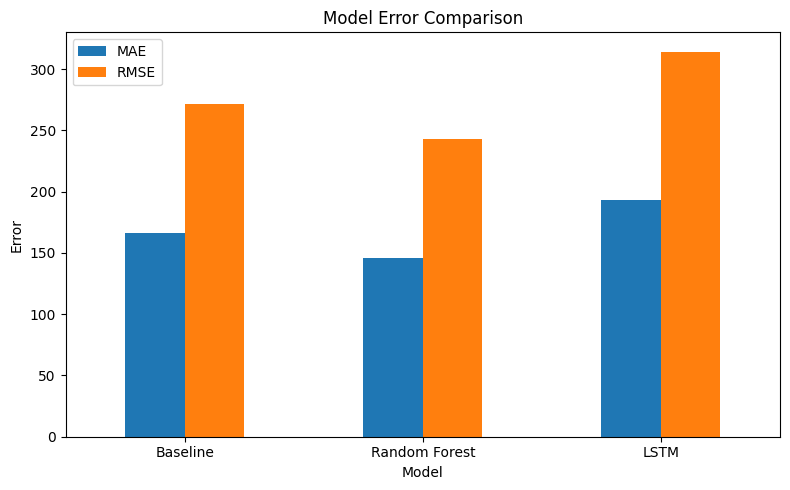

In [21]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
from pathlib import Path

output_path = Path("../outputs")
output_path.mkdir(exist_ok=True)

comparison_df.to_csv(output_path / "final_model_comparison_with_lstm.csv", index=False)
print("Final comparison with LSTM saved.")

Final comparison with LSTM saved.


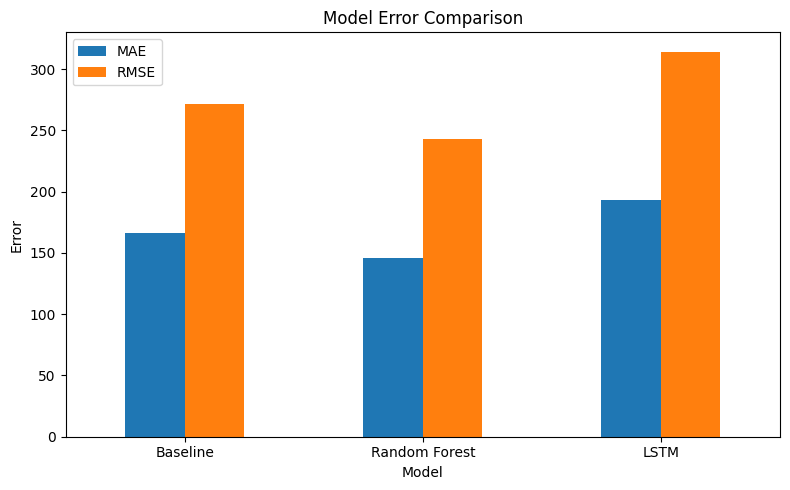

In [23]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(output_path / "model_error_comparison_with_lstm.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
lstm_results_df = pd.DataFrame({
    "actual": y_test_actual.flatten(),
    "predicted": lstm_preds.flatten()
})

lstm_results_df.to_csv(output_path / "lstm_predictions.csv", index=False)
print("LSTM predictions saved.")

LSTM predictions saved.
